In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import parallel_coordinates
import seaborn as sns
import numpy as np

# df_PT

In [9]:
Student_dropout = pd.read_csv('data/data.csv', sep=';')

In [10]:
Student_dropout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [11]:
Student_dropout['Target'] = Student_dropout['Target'].replace('Graduate', 0).replace('Enrolled', 0).replace('Dropout', 1)

C:\Users\gusta\AppData\Local\Temp\ipykernel_18408\398414641.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Student_dropout['Target'] = Student_dropout['Target'].replace('Graduate', 0).replace('Enrolled', 0).replace('Dropout', 1)


### Variáveis
- Todas as variáveis estão oficialmente em int ou float, garantindo que consiguimos comparar eles de maneira numérica

In [12]:
binary = [
    'Gender',
    'Displaced',
    'Scolarship Holder',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date'
]

Continuous= [
    'Admission grade',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

In [13]:
drop = [col for col in Student_dropout.columns if col.startswith('Curricular units 2nd sem') and col != 'Curricular units 2nd sem (without evaluations)'] + ['Father\'s occupation', 'International']
Student_dropout.drop(columns=drop, inplace=True)

# Coding
Now that we cleaned our database and treated any thing that could cause trouble, it's time we start coding

In [14]:
from imblearn.over_sampling import RandomOverSampler
def oversampling(X, y):
    sampler = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = sampler.fit_resample(X, y)
    return X_resampled, y_resampled

In [15]:
import sklearn.model_selection

y = Student_dropout['Target']
X = Student_dropout.drop(columns=['Target'])

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
X_oversampled, y_oversampled = oversampling(X_train, y_train)

In [16]:
from numbers import Number

class Question():
    def __init__(self, column, value):
        self.column = column
        self.value = value
    
    def match(self, example):
        val =example[self.column]
        if isinstance(val, Number):
            return val >= self.value
        else:
            return val == self.value

    def __repr__(self):
        condition = "=="
        if isinstance(self.value, (int, float)):
            condition = ">="
        return f"Is {self.column} {condition} {str(self.value)}?"

In [17]:

def partition(rows, y, question):
    """
    Divide os dados de cada uma das linhas em duas listas,
    A primeira tem todos aqueles que respondem a pergunta;
    Já a segunda tem todos aqueles que não respondem a pergunta.
    """
    true_rows, false_rows = [], []
    true_labels, false_labels = [], []

    for row, label in zip(rows, y):
        if question.match(row):
            true_rows.append(row)
            true_labels.append(label)
        else:
            false_rows.append(row)
            false_labels.append(label)

    true_rows = np.array(true_rows)
    true_labels = np.array(true_labels)
    false_rows = np.array(false_rows)
    false_labels = np.array(false_labels)

    return (true_rows, true_labels), (false_rows, false_labels)

def class_counts(rows):  
    #Lista quantas vezes aparece na coluna de evasão os evadidos e não evadidos 
    counts = {}
    for row in rows:
        label = row[-1]
        
        if label not in counts:
            counts[label]=1
        else: 
            counts[label]+=1
    return counts


def gini(rows):
    counts =class_counts(rows)
    impurity = 1
    for lbl in counts:
        prob_lbl = counts[lbl]/float(len(rows))
        impurity -= prob_lbl**2

    return impurity

def info_gain(left, right, current_uncertainty):
    p = float(len(left))/(len(left) + len(right))
    return current_uncertainty - p *gini(left) - (1-p) * gini(right)
    
def find_best_split(rows, y, n_features):
    """
    Define a melhor pergunta para dividir os dados com base 
    no ganho de conhecimento (information gain) e no índice de Gini.
    """
    best_gain = 0
    best_question = None
    curr_gini = gini(rows)

    for col in range(n_features):
        values = set([row[col] for row in rows])

        for val in values:
                  
            question = Question(col, val)
            true_rows, false_rows = partition(rows, y, question)

            if len(true_rows) and len(false_rows):
                gain = info_gain(true_rows[0], false_rows[0], curr_gini)
                if gain >= best_gain: best_gain, best_question = gain, question

    return best_gain, best_question

In [18]:
from collections import Counter
class DecisionNode():
    #Tem filhos, é uma etapa de pergunta, e não uma folha da árvore de decisão.
    def __init__(self, question, true_branch, false_branch):
        self.question = question
        self.true_branch = true_branch
        self.false_branch = false_branch

    def predict(self, row):
        if isinstance(self, Leaf):
            return self.predictions
        if self.question.match(row):
            return self.true_branch.predict(row)
        else:
            return self.false_branch.predict(row)
        
    def predict_all(self, rows):
        return [self.predict(row) for row in rows]

class Leaf():
    #Não tem filhos, é a resposta final da árvore de decisão.
    def __init__(self, predictions):
        self.predictions = Counter(predictions).most_common(1)[0][0]

    def predict(self, row):
        return self.predictions

In [19]:
class DecisionTree():
    def __init__(self, x, y, minSplit = 2, maxDepth = 5, n_features=29):
        self.x = x
        self.y = y
        self.minSplit = minSplit
        self.maxDepth = maxDepth
        self.n_features = n_features
        
    def buildTree(self, curr_depth = 0):
        #Constrói a árvore de decisão recursivamente.
        n_samples= len(self.x)
        if n_samples < self.minSplit or self.maxDepth == 0:
            return Leaf(self.y)
        self.maxDepth -= 1
        gain, question = find_best_split(self.x, self.y, self.n_features)

        if gain == 0:
            return Leaf(self.y)
        (true_rows, true_labels), (false_rows, false_labels) = partition(self.x, self.y, question)


        if len(true_rows) == 0 or len(false_rows) == 0:
            return Leaf(self.y)
        
        curr_depth =+ 1
        true_branch = DecisionTree(true_rows, true_labels, self.minSplit, self.maxDepth).buildTree(curr_depth)
        false_branch = DecisionTree(false_rows, false_labels, self.minSplit, self.maxDepth).buildTree(curr_depth)

        return DecisionNode(question, true_branch, false_branch)

        
    

## Random Forest


Random forets são um coletivo de árvores de decisão treinadas com um conjunto de dados selecionados aleatoriamente e com reposição em um data set. Além disso, os features analisados são também escolhidos de maneira aleatória

In [20]:

import random


class randomForest():
    def __init__(self, n_trees=10, minSplit=2, maxDepth=5, sample_size=10):
        self.n_trees = n_trees
        self.minSplit = minSplit
        self.maxDepth = maxDepth
        self.sample_size = sample_size
        self.trees = []

    def buildForest(self, x, y):
        for i in range(self.n_trees):
            indices = random.sample(range(len(x)), k=self.sample_size)
            new_x = x[indices]
            new_y = y[indices]
            tree = DecisionTree(new_x, new_y, self.minSplit, self.maxDepth)
            self.trees.append(tree.buildTree())
        
        return self.trees
    
    def predict(self, row):
        predictions = [tree.predict(row) for tree in self.trees]
        
        count = Counter(predictions)
        classe_mais_votada, _ = count.most_common(1)[0]
        
        return classe_mais_votada
    
    def predict_all(self, rows):
        return [self.predict(row) for row in rows]

In [25]:
myForest = randomForest()
myForest.buildForest(X_train.values, y_train.values)
myForestPredictions = myForest.predict_all(X_test.values)

myOverForest = randomForest()
myOverForest.buildForest(X_oversampled.values, y_oversampled.values)
myOverForestPredictions = myOverForest.predict_all(X_test.values)

In [26]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
forestPredictions = forest.predict(X_test)

overForest = RandomForestClassifier(n_estimators=100, random_state=42)
overForest.fit(X_oversampled, y_oversampled)
overForestPredictions = overForest.predict(X_test)

# Comparação dos resultados

Acurácia da Árvore de Decisão Normal:
0.8384180790960452
Matriz de Confusão da Árvore de Decisão Normal:


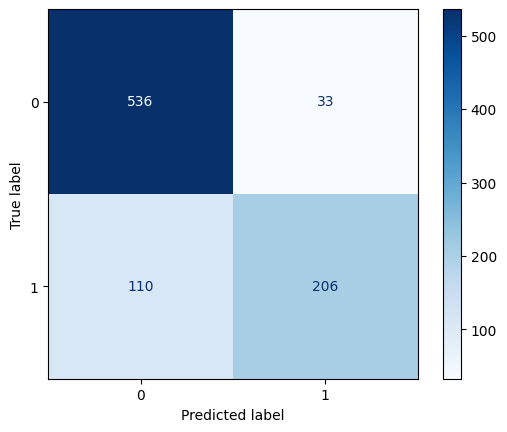

------------------------------------


Acurácia da Árvore de Decisão com Dados Oversampled:
0.8451977401129943
Matriz de Confusão da Árvore de Decisão com Dados Oversampled:


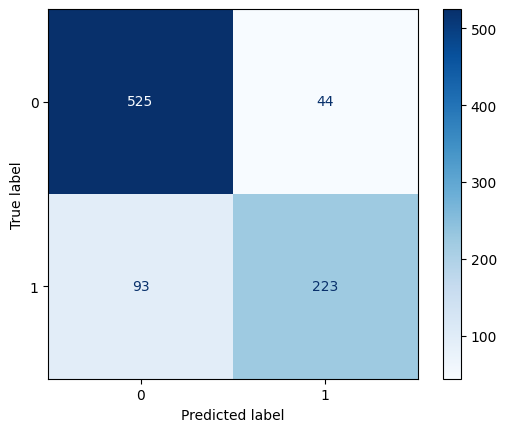

------------------------------------


Acurácia da Árvore de Decisão Implementada:
0.6429378531073446
Matriz de Confusão da Árvore de Decisão Implementada:


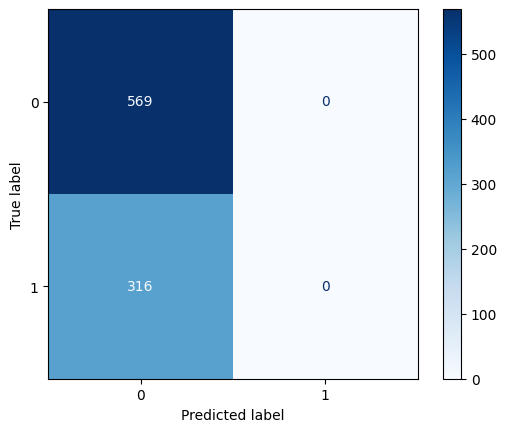

------------------------------------


Acurácia da Árvore de Decisão Implementada com Dados Oversampled:
0.5548022598870056
Matriz de Confusão da Árvore de Decisão Implementada com Dados Oversampled:


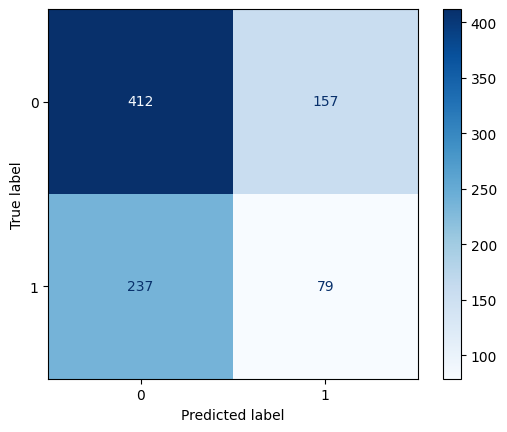

------------------------------------




In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ----------------------------------- #
# =========== Acurácia ============== #
# ----------------------------------- #


print("Acurácia da Árvore de Decisão Normal:")
print(accuracy_score(y_test, forestPredictions))
print("Matriz de Confusão da Árvore de Decisão Normal:")
cm = confusion_matrix(y_test, forestPredictions)
disp=ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()
print("------------------------------------")
print("\n")

print("Acurácia da Árvore de Decisão com Dados Oversampled:")
print(accuracy_score(y_test, overForestPredictions))
print("Matriz de Confusão da Árvore de Decisão com Dados Oversampled:")
cm = confusion_matrix(y_test, overForestPredictions)
disp=ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()
print("------------------------------------")
print("\n")

print("Acurácia da Árvore de Decisão Implementada:")
print(accuracy_score(y_test, myForestPredictions))
print("Matriz de Confusão da Árvore de Decisão Implementada:")
cm = confusion_matrix(y_test, myForestPredictions)
disp=ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()
print("------------------------------------")
print("\n")

print("Acurácia da Árvore de Decisão Implementada com Dados Oversampled:")
print(accuracy_score(y_test, myOverForestPredictions))
print("Matriz de Confusão da Árvore de Decisão Implementada com Dados Oversampled:")
cm = confusion_matrix(y_test, myOverForestPredictions)
disp=ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()
print("------------------------------------")
print("\n")